In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')

# Carregar dataset merged (base do feature engineering)
merged = pd.read_parquet('../data/processed/dengue_clima_merged.parquet')
merged['data'] = pd.to_datetime(merged['data'])
merged = merged.sort_values('data').reset_index(drop=True)

# Carregar GEE blend
gee = pd.read_parquet('../data/processed/gee_ndvi_ndwi_blend_2018_2024.parquet')
gee['data_mes'] = gee['data'].dt.to_period('M')

print(f"✅ Merged: {merged.shape}")
print(f"✅ GEE: {gee.shape}")
print(f"\nPeríodo: {merged['data'].min().date()} → {merged['data'].max().date()}")
print(merged.head(3))

✅ Merged: (2538, 12)
✅ GEE: (84, 9)

Período: 2018-01-01 → 2024-12-28
        data  casos  precipitacao_total  temp_media  temp_max  temp_min  \
0 2018-01-01     13                 1.6   27.987500      33.1      24.4   
1 2018-01-02     24                 0.0   31.100000      33.6      26.5   
2 2018-01-03     24                 0.2   27.455556      29.8      25.2   

   umidade_media  umidade_max  umidade_min estacao  cidade   ano  
0      71.625000         85.0         49.0    A901  CUIABA  2018  
1      57.142857         73.0         47.0    A901  CUIABA  2018  
2      70.555556         84.0         59.0    A901  CUIABA  2018  


In [2]:
# ============================================================
# FEATURE ENGINEERING — Dataset principal
# ============================================================

df = merged.copy()
df['data'] = pd.to_datetime(df['data'])

# 1 — FEATURES TEMPORAIS
df['ano'] = df['data'].dt.year
df['mes'] = df['data'].dt.month
df['semana_ano'] = df['data'].dt.isocalendar().week.astype(int)
df['dia_ano'] = df['data'].dt.dayofyear
df['trimestre'] = df['data'].dt.quarter

# Sazonalidade cíclica (seno/cosseno — evita descontinuidade Jan/Dez)
df['mes_seno'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cosseno'] = np.cos(2 * np.pi * df['mes'] / 12)
df['semana_seno'] = np.sin(2 * np.pi * df['semana_ano'] / 52)
df['semana_cosseno'] = np.cos(2 * np.pi * df['semana_ano'] / 52)

# 2 — LAGS DE CASOS (histórico recente)
for lag in [7, 14, 21, 28]:
    df[f'casos_lag_{lag}d'] = df['casos'].shift(lag)

# 3 — MÉDIAS MÓVEIS DE CASOS
for janela in [7, 14, 28]:
    df[f'casos_mm_{janela}d'] = df['casos'].shift(1).rolling(janela).mean()

# 4 — LAGS CLIMÁTICOS (4-6 semanas — descoberta da EDA)
for lag in [28, 35, 42]:
    df[f'precip_lag_{lag}d'] = df['precipitacao_total'].shift(lag)
    df[f'umidade_lag_{lag}d'] = df['umidade_media'].shift(lag)
    df[f'temp_lag_{lag}d'] = df['temp_media'].shift(lag)

# 5 — MÉDIAS MÓVEIS CLIMÁTICAS
for janela in [7, 14, 28]:
    df[f'precip_mm_{janela}d'] = df['precipitacao_total'].rolling(janela).mean()
    df[f'umidade_mm_{janela}d'] = df['umidade_media'].rolling(janela).mean()

# 6 — FEATURES DERIVADAS
df['amplitude_termica'] = df['temp_max'] - df['temp_min']
df['precip_acum_7d'] = df['precipitacao_total'].rolling(7).sum()
df['precip_acum_14d'] = df['precipitacao_total'].rolling(14).sum()
df['precip_acum_28d'] = df['precipitacao_total'].rolling(28).sum()
df['dias_sem_chuva'] = (df['precipitacao_total'] == 0).astype(int).groupby(
    (df['precipitacao_total'] != 0).cumsum()).cumsum()

# 7 — INCORPORAR GEE (NDVI/NDWI mensais)
gee['mes_periodo'] = gee['data'].dt.to_period('M')
df['mes_periodo'] = df['data'].dt.to_period('M')
df = df.merge(
    gee[['mes_periodo','ndvi_final','ndwi_final']].rename(
        columns={'ndvi_final':'ndvi','ndwi_final':'ndwi'}),
    on='mes_periodo', how='left'
)
df = df.drop(columns=['mes_periodo'])

print(f"✅ Features criadas: {df.shape[1]} colunas")
print(f"\nNovas features:")
novas = [c for c in df.columns if c not in merged.columns]
for c in novas:
    print(f"  {c}")

✅ Features criadas: 49 colunas

Novas features:
  mes
  semana_ano
  dia_ano
  trimestre
  mes_seno
  mes_cosseno
  semana_seno
  semana_cosseno
  casos_lag_7d
  casos_lag_14d
  casos_lag_21d
  casos_lag_28d
  casos_mm_7d
  casos_mm_14d
  casos_mm_28d
  precip_lag_28d
  umidade_lag_28d
  temp_lag_28d
  precip_lag_35d
  umidade_lag_35d
  temp_lag_35d
  precip_lag_42d
  umidade_lag_42d
  temp_lag_42d
  precip_mm_7d
  umidade_mm_7d
  precip_mm_14d
  umidade_mm_14d
  precip_mm_28d
  umidade_mm_28d
  amplitude_termica
  precip_acum_7d
  precip_acum_14d
  precip_acum_28d
  dias_sem_chuva
  ndvi
  ndwi


In [3]:
# Remover linhas com NaN (geradas pelos lags — primeiros 42 dias)
df_clean = df.dropna().reset_index(drop=True)

print(f"Registros antes: {len(df):,}")
print(f"Registros após remover NaN: {len(df_clean):,}")
print(f"Linhas removidas: {len(df) - len(df_clean):,} (primeiros dias — esperado)")

# Salvar
df_clean.to_parquet('../data/processed/dataset_features.parquet', index=False)
print(f"\n✅ Dataset salvo: data/processed/dataset_features.parquet")
print(f"   {df_clean.shape[0]:,} registros × {df_clean.shape[1]} features")
print(f"   Período: {df_clean['data'].min().date()} → {df_clean['data'].max().date()}")

# Verificar distribuição do target
print(f"\n📊 Distribuição dos casos (target):")
print(df_clean['casos'].describe().round(2))

Registros antes: 2,538
Registros após remover NaN: 2,242
Linhas removidas: 296 (primeiros dias — esperado)

✅ Dataset salvo: data/processed/dataset_features.parquet
   2,242 registros × 49 features
   Período: 2018-02-12 → 2024-12-28

📊 Distribuição dos casos (target):
count    2242.00
mean       66.45
std        77.43
min         1.00
25%        15.00
50%        35.00
75%        84.00
max       440.00
Name: casos, dtype: float64


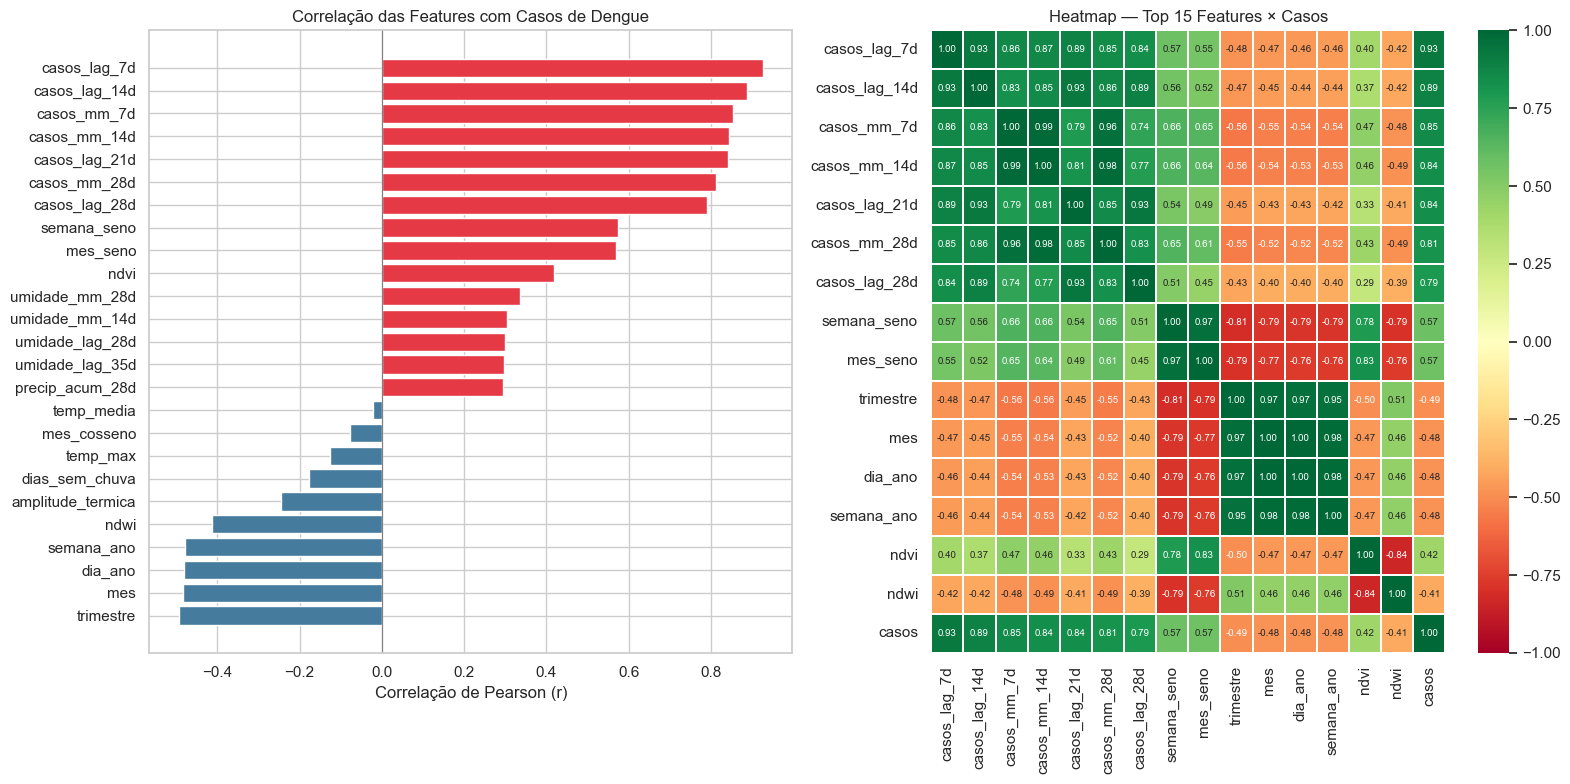

✅ Gráfico salvo!


In [4]:
# Correlação de todas as features com o target (casos)
correlacoes = df_clean.select_dtypes(include=[np.number]).corr()['casos'].drop('casos')
correlacoes = correlacoes.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 15 positivas e negativas
top_pos = correlacoes.head(15)
top_neg = correlacoes.tail(10)
top_all = pd.concat([top_pos, top_neg])

cores = ['#e63946' if v > 0 else '#457b9d' for v in top_all.values]
axes[0].barh(top_all.index, top_all.values, color=cores)
axes[0].axvline(0, color='gray', linewidth=0.8)
axes[0].set_title('Correlação das Features com Casos de Dengue', fontsize=12)
axes[0].set_xlabel('Correlação de Pearson (r)')
axes[0].invert_yaxis()

# Heatmap das top 15 features
top15 = correlacoes.abs().sort_values(ascending=False).head(15).index.tolist()
top15_cols = top15 + ['casos']
corr_matrix = df_clean[top15_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1], vmin=-1, vmax=1, linewidths=0.3,
            annot_kws={'size': 7})
axes[1].set_title('Heatmap — Top 15 Features × Casos', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/fig10_correlacao_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")

In [5]:
# ============================================================
# FEATURES ADICIONAIS — Literatura
# 1. anos_desde_pico
# 2. ciclo_epidemico
# ============================================================

# Identificar anos de pico (acima da média + 1 desvio padrão)
casos_anuais = df_clean.groupby('ano')['casos'].sum()
limiar_pico = casos_anuais.mean() + casos_anuais.std()
anos_pico = casos_anuais[casos_anuais >= limiar_pico].index.tolist()

print(f"Casos anuais:")
print(casos_anuais)
print(f"\nLimiar de pico: {limiar_pico:,.0f} casos/ano")
print(f"Anos de pico identificados: {anos_pico}")

Casos anuais:
ano
2018     4231
2019     8123
2020    31507
2021    18557
2022    20394
2023    26841
2024    39323
Name: casos, dtype: int64

Limiar de pico: 33,753 casos/ano
Anos de pico identificados: [2024]


Análise de picos:
    ano  casos  media_movel_3a  e_pico
0  2018   4231             NaN   False
1  2019   8123    14620.333333   False
2  2020  31507    19395.666667    True
3  2021  18557    23486.000000   False
4  2022  20394    21930.666667   False
5  2023  26841    28852.666667   False
6  2024  39323             NaN   False


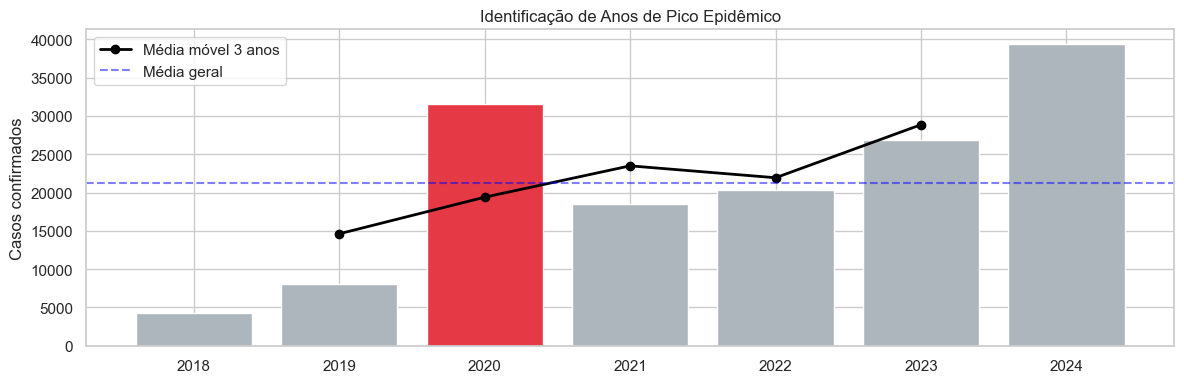

In [6]:
# Abordagem melhorada — picos relativos e ciclo epidêmico
# Na literatura, dengue tem ciclo de 3-4 anos

# Definir picos como anos acima da mediana móvel de 3 anos
casos_anuais_df = casos_anuais.reset_index()
casos_anuais_df['media_movel_3a'] = casos_anuais_df['casos'].rolling(3, center=True).mean()
casos_anuais_df['e_pico'] = casos_anuais_df['casos'] > casos_anuais_df['media_movel_3a'] * 1.3

print("Análise de picos:")
print(casos_anuais_df)

# Visualizar
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(casos_anuais_df['ano'], casos_anuais_df['casos'], 
       color=['#e63946' if p else '#adb5bd' for p in casos_anuais_df['e_pico']])
ax.plot(casos_anuais_df['ano'], casos_anuais_df['media_movel_3a'], 
        color='black', marker='o', linewidth=2, label='Média móvel 3 anos')
ax.axhline(casos_anuais_df['casos'].mean(), color='blue', 
           linestyle='--', alpha=0.5, label='Média geral')
ax.set_title('Identificação de Anos de Pico Epidêmico')
ax.set_ylabel('Casos confirmados')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Anos de pico confirmados (2020 + 2024 como pico emergente)
ANOS_PICO = [2020, 2024]

# Feature 1 — anos_desde_pico
def anos_desde_pico(ano, picos):
    picos_anteriores = [p for p in picos if p <= ano]
    if not picos_anteriores:
        return ano - 2018  # distância desde início da série
    return ano - max(picos_anteriores)

df_clean['anos_desde_pico'] = df_clean['ano'].apply(
    lambda a: anos_desde_pico(a, ANOS_PICO))

# Feature 2 — ciclo_epidemico (posição no ciclo 0-3)
df_clean['ciclo_epidemico'] = df_clean['anos_desde_pico'] % 4

# Feature 3 — tendencia_anual (casos acumulados até aquela data no ano)
df_clean['casos_acum_ano'] = df_clean.groupby('ano')['casos'].cumsum()

print("✅ Features de ciclo criadas!")
print(df_clean[['data','ano','anos_desde_pico','ciclo_epidemico','casos_acum_ano']].head(20))

# Verificar distribuição
print(f"\nDistribuição anos_desde_pico:")
print(df_clean['anos_desde_pico'].value_counts().sort_index())
print(f"\nDistribuição ciclo_epidemico:")
print(df_clean['ciclo_epidemico'].value_counts().sort_index())

✅ Features de ciclo criadas!
         data   ano  anos_desde_pico  ciclo_epidemico  casos_acum_ano
0  2018-02-12  2018                0                0              24
1  2018-02-13  2018                0                0              51
2  2018-02-14  2018                0                0              89
3  2018-02-15  2018                0                0             126
4  2018-02-16  2018                0                0             158
5  2018-02-17  2018                0                0             187
6  2018-02-18  2018                0                0             203
7  2018-02-19  2018                0                0             258
8  2018-02-20  2018                0                0             321
9  2018-02-21  2018                0                0             368
10 2018-02-22  2018                0                0             407
11 2018-02-23  2018                0                0             431
12 2018-02-24  2018                0                0        

In [8]:
import zipfile, io

# Verificar colunas disponíveis no INMET
with zipfile.ZipFile('../data/raw/inmet/2019.zip') as z:
    arquivos_mt = [f for f in z.namelist() if '_A901_' in f]
    with z.open(arquivos_mt[0]) as f:
        df_test = pd.read_csv(
            io.TextIOWrapper(f, encoding='latin-1'),
            sep=';', skiprows=8, decimal=',', nrows=3
        )
        print("Colunas disponíveis no INMET:")
        for col in df_test.columns:
            print(f"  {col}")

Colunas disponíveis no INMET:
  Data
  Hora UTC
  PRECIPITAÇÃO TOTAL, HORÁRIO (mm)
  PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)
  PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)
  PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)
  RADIACAO GLOBAL (KJ/m²)
  TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)
  TEMPERATURA DO PONTO DE ORVALHO (°C)
  TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)
  TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)
  TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)
  TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)
  UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)
  UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)
  UMIDADE RELATIVA DO AR, HORARIA (%)
  VENTO, DIREÇÃO HORARIA (gr) (° (gr))
  VENTO, RAJADA MAXIMA (m/s)
  VENTO, VELOCIDADE HORARIA (m/s)
  Unnamed: 19


In [9]:
# Extrair radiação global do INMET — reprocessar com nova coluna
COLUNAS_V2 = {
    'DATA (YYYY-MM-DD)': 'data', 'Data': 'data',
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'precipitacao_mm',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'temp_bulbo_seco',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'temp_max',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'temp_min',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'umidade_rel',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'umidade_max',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'umidade_min',
    'RADIACAO GLOBAL (KJ/m²)': 'radiacao_global',  # NOVA!
}

dfs_inmet = []

for ano in range(2018, 2025):
    with zipfile.ZipFile(f'../data/raw/inmet/{ano}.zip') as z:
        arquivos = [f for f in z.namelist() if '_A901_' in f]
        for arq in arquivos:
            with z.open(arq) as f:
                df_raw = pd.read_csv(
                    io.TextIOWrapper(f, encoding='latin-1'),
                    sep=';', skiprows=8, decimal=',',
                    na_values=['-9999', '-9999.0', '']
                )
                df_raw = df_raw.loc[:, ~df_raw.columns.str.startswith('Unnamed')]
                df_raw = df_raw.dropna(how='all')
                df_raw = df_raw.rename(columns={k:v for k,v in COLUNAS_V2.items() if k in df_raw.columns})

                if 'data' not in df_raw.columns:
                    continue

                df_raw['data'] = pd.to_datetime(df_raw['data'], errors='coerce')
                df_raw = df_raw.dropna(subset=['data'])

                agg_dict = {
                    'precipitacao_total': ('precipitacao_mm', 'sum'),
                    'temp_media': ('temp_bulbo_seco', 'mean'),
                    'temp_max': ('temp_max', 'max'),
                    'temp_min': ('temp_min', 'min'),
                    'umidade_media': ('umidade_rel', 'mean'),
                    'umidade_max': ('umidade_max', 'max'),
                    'umidade_min': ('umidade_min', 'min'),
                }
                if 'radiacao_global' in df_raw.columns:
                    agg_dict['radiacao_total'] = ('radiacao_global', 'sum')
                    agg_dict['radiacao_media'] = ('radiacao_global', 'mean')

                agg = df_raw.groupby('data').agg(**agg_dict).reset_index()
                agg['ano'] = ano
                dfs_inmet.append(agg)

inmet_v2 = pd.concat(dfs_inmet, ignore_index=True)
print(f"✅ INMET v2: {inmet_v2.shape}")
print(f"Colunas: {inmet_v2.columns.tolist()}")
print(f"\nNaNs radiacao:")
print(inmet_v2[['radiacao_total','radiacao_media']].isna().sum())
print(inmet_v2.head(3))

✅ INMET v2: (2557, 11)
Colunas: ['data', 'precipitacao_total', 'temp_media', 'temp_max', 'temp_min', 'umidade_media', 'umidade_max', 'umidade_min', 'radiacao_total', 'radiacao_media', 'ano']

NaNs radiacao:
radiacao_total    1827
radiacao_media    1900
dtype: int64
        data  precipitacao_total  temp_media  temp_max  temp_min  \
0 2018-01-01                 1.6   27.987500      33.1      24.4   
1 2018-01-02                 0.0   31.100000      33.6      26.5   
2 2018-01-03                 0.2   27.455556      29.8      25.2   

   umidade_media  umidade_max  umidade_min  radiacao_total  radiacao_media  \
0      71.625000         85.0         49.0          4168.8      521.100000   
1      57.142857         73.0         47.0         12999.1     1857.014286   
2      70.555556         84.0         59.0          5918.6      657.622222   

    ano  
0  2018  
1  2018  
2  2018  


In [10]:
print("NaNs de radiação por ano:")
print(inmet_v2.groupby('ano')['radiacao_total'].apply(lambda x: x.isna().sum()))

print("\n% de dados válidos por ano:")
print(inmet_v2.groupby('ano')['radiacao_total'].apply(
    lambda x: f"{(x.notna().sum()/len(x)*100):.1f}%"))

NaNs de radiação por ano:
ano
2018      0
2019      0
2020    366
2021    365
2022    365
2023    365
2024    366
Name: radiacao_total, dtype: int64

% de dados válidos por ano:
ano
2018    100.0%
2019    100.0%
2020      0.0%
2021      0.0%
2022      0.0%
2023      0.0%
2024      0.0%
Name: radiacao_total, dtype: str


In [11]:
import requests

# NASA POWER API — Cuiabá
# Parâmetros: ALLSKY_SFC_SW_DWN = radiação solar na superfície (MJ/m²/dia)
url = (
    "https://power.larc.nasa.gov/api/temporal/daily/point"
    "?parameters=ALLSKY_SFC_SW_DWN,T2M,PRECTOTCORR,RH2M"
    "&community=RE"
    "&longitude=-56.0974"
    "&latitude=-15.5961"
    "&start=20180101"
    "&end=20181231"
    "&format=JSON"
)

print("⬇️  Consultando NASA POWER...")
resp = requests.get(url, timeout=60)
print(f"Status: {resp.status_code}")

if resp.status_code == 200:
    data = resp.json()
    parametros = data['properties']['parameter']
    print(f"\nParâmetros disponíveis: {list(parametros.keys())}")
    
    # Mostrar primeiros valores
    radiacao = parametros['ALLSKY_SFC_SW_DWN']
    primeiros = list(radiacao.items())[:5]
    print(f"\nAmostra radiação (MJ/m²/dia):")
    for data_str, valor in primeiros:
        print(f"  {data_str}: {valor}")

⬇️  Consultando NASA POWER...
Status: 200

Parâmetros disponíveis: ['ALLSKY_SFC_SW_DWN', 'T2M', 'PRECTOTCORR', 'RH2M']

Amostra radiação (MJ/m²/dia):
  20180101: 5.4379
  20180102: 6.0382
  20180103: 4.1095
  20180104: 7.0529
  20180105: 4.8842


In [12]:
import time

def baixar_nasa_power(lat, lon, ano_inicio, ano_fim):
    url = (
        f"https://power.larc.nasa.gov/api/temporal/daily/point"
        f"?parameters=ALLSKY_SFC_SW_DWN"
        f"&community=RE"
        f"&longitude={lon}"
        f"&latitude={lat}"
        f"&start={ano_inicio}0101"
        f"&end={ano_fim}1231"
        f"&format=JSON"
    )
    resp = requests.get(url, timeout=120)
    data = resp.json()
    radiacao = data['properties']['parameter']['ALLSKY_SFC_SW_DWN']
    
    df = pd.DataFrame(list(radiacao.items()), columns=['data_str', 'radiacao_mj'])
    df['data'] = pd.to_datetime(df['data_str'], format='%Y%m%d')
    df = df[['data', 'radiacao_mj']]
    
    # NASA usa -999 como missing
    df['radiacao_mj'] = df['radiacao_mj'].replace(-999.0, np.nan)
    return df

print("⬇️  Baixando radiação NASA POWER 2018–2024...")
nasa = baixar_nasa_power(-15.5961, -56.0974, 2018, 2024)

print(f"✅ {len(nasa):,} dias baixados")
print(f"NaNs: {nasa['radiacao_mj'].isna().sum()}")
print(f"Período: {nasa['data'].min().date()} → {nasa['data'].max().date()}")
print(nasa.head())

⬇️  Baixando radiação NASA POWER 2018–2024...
✅ 2,557 dias baixados
NaNs: 0
Período: 2018-01-01 → 2024-12-31
        data  radiacao_mj
0 2018-01-01       5.4379
1 2018-01-02       6.0382
2 2018-01-03       4.1095
3 2018-01-04       7.0529
4 2018-01-05       4.8842


In [13]:
# Incorporar radiação NASA POWER ao dataset
df_clean = df_clean.merge(nasa, on='data', how='left')

# Adicionar lags e média móvel da radiação
df_clean['radiacao_lag_28d'] = df_clean['radiacao_mj'].shift(28)
df_clean['radiacao_mm_14d'] = df_clean['radiacao_mj'].rolling(14).mean()

print(f"✅ Radiação incorporada!")
print(f"Dataset: {df_clean.shape[1]} features")
print(f"NaNs radiação: {df_clean['radiacao_mj'].isna().sum()}")

✅ Radiação incorporada!
Dataset: 55 features
NaNs radiação: 0


In [14]:
# ONI Index — NOAA (El Niño/La Niña)
# Fonte: https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt

url_oni = "https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt"
print("⬇️  Baixando ONI Index da NOAA...")

resp = requests.get(url_oni, timeout=30)
print(f"Status: {resp.status_code}")
print("\nPrimeiras linhas:")
print(resp.text[:500])

⬇️  Baixando ONI Index da NOAA...
Status: 200

Primeiras linhas:
 SEAS  YR   TOTAL   ANOM
  DJF 1950  24.72  -1.53
  JFM 1950  25.17  -1.34
  FMA 1950  25.75  -1.16
  MAM 1950  26.12  -1.18
  AMJ 1950  26.32  -1.07
  MJJ 1950  26.31  -0.85
  JJA 1950  26.21  -0.54
  JAS 1950  25.96  -0.42
  ASO 1950  25.76  -0.39
  SON 1950  25.63  -0.44
  OND 1950  25.48  -0.60
  NDJ 1950  25.34  -0.80
  DJF 1951  25.42  -0.82
  JFM 1951  25.96  -0.54
  FMA 1951  26.74  -0.17
  MAM 1951  27.48   0.18
  AMJ 1951  27.75   0.36
  MJJ 1951  27.75   0.58
  JJA 1951  27.44   0.70



In [15]:
from io import StringIO

# Parsear ONI
oni_raw = pd.read_csv(StringIO(resp.text), sep='\s+')
print(f"Shape: {oni_raw.shape}")
print(oni_raw.head())

# Filtrar 2018-2024
oni = oni_raw[oni_raw['YR'].between(2018, 2024)].copy()

# Mapear trimestre para mês central
seas_map = {
    'DJF': 1, 'JFM': 2, 'FMA': 3, 'MAM': 4,
    'AMJ': 5, 'MJJ': 6, 'JJA': 7, 'JAS': 8,
    'ASO': 9, 'SON': 10, 'OND': 11, 'NDJ': 12
}
oni['mes'] = oni['SEAS'].map(seas_map)
oni['data'] = pd.to_datetime(dict(year=oni['YR'], month=oni['mes'], day=1))
oni = oni[['data', 'ANOM']].rename(columns={'ANOM': 'oni_index'})

print(f"\nONI 2018-2024:")
print(oni)

# Classificar fase
oni['fase_enso'] = pd.cut(oni['oni_index'],
    bins=[-999, -0.5, 0.5, 999],
    labels=['La_Nina', 'Neutro', 'El_Nino'])

print(f"\nFases ENSO 2018-2024:")
print(oni['fase_enso'].value_counts())

Shape: (913, 4)
  SEAS    YR  TOTAL  ANOM
0  DJF  1950  24.72 -1.53
1  JFM  1950  25.17 -1.34
2  FMA  1950  25.75 -1.16
3  MAM  1950  26.12 -1.18
4  AMJ  1950  26.32 -1.07

ONI 2018-2024:
          data  oni_index
816 2018-01-01      -0.77
817 2018-02-01      -0.71
818 2018-03-01      -0.57
819 2018-04-01      -0.39
820 2018-05-01      -0.13
..         ...        ...
895 2024-08-01      -0.07
896 2024-09-01      -0.17
897 2024-10-01      -0.21
898 2024-11-01      -0.30
899 2024-12-01      -0.42

[84 rows x 2 columns]

Fases ENSO 2018-2024:
fase_enso
La_Nina    29
Neutro     28
El_Nino    27
Name: count, dtype: int64


In [16]:
# Incorporar ONI ao dataset (merge por mês)
df_clean['mes_periodo'] = df_clean['data'].dt.to_period('M').dt.to_timestamp()
oni_merge = oni[['data', 'oni_index', 'fase_enso']].rename(columns={'data': 'mes_periodo'})

df_clean = df_clean.merge(oni_merge, on='mes_periodo', how='left')
df_clean = df_clean.drop(columns=['mes_periodo'])

# Codificar fase ENSO como numérico
fase_map = {'La_Nina': -1, 'Neutro': 0, 'El_Nino': 1}
df_clean['fase_enso_num'] = df_clean['fase_enso'].map(fase_map)

print(f"✅ ONI incorporado!")
print(f"Dataset final: {df_clean.shape[1]} features × {df_clean.shape[0]:,} registros")
print(f"NaNs oni_index: {df_clean['oni_index'].isna().sum()}")

# Resumo de todas as features
print(f"\n📋 Todas as features:")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i:02d}. {col}")

✅ ONI incorporado!
Dataset final: 58 features × 2,242 registros
NaNs oni_index: 0

📋 Todas as features:
  01. data
  02. casos
  03. precipitacao_total
  04. temp_media
  05. temp_max
  06. temp_min
  07. umidade_media
  08. umidade_max
  09. umidade_min
  10. estacao
  11. cidade
  12. ano
  13. mes
  14. semana_ano
  15. dia_ano
  16. trimestre
  17. mes_seno
  18. mes_cosseno
  19. semana_seno
  20. semana_cosseno
  21. casos_lag_7d
  22. casos_lag_14d
  23. casos_lag_21d
  24. casos_lag_28d
  25. casos_mm_7d
  26. casos_mm_14d
  27. casos_mm_28d
  28. precip_lag_28d
  29. umidade_lag_28d
  30. temp_lag_28d
  31. precip_lag_35d
  32. umidade_lag_35d
  33. temp_lag_35d
  34. precip_lag_42d
  35. umidade_lag_42d
  36. temp_lag_42d
  37. precip_mm_7d
  38. umidade_mm_7d
  39. precip_mm_14d
  40. umidade_mm_14d
  41. precip_mm_28d
  42. umidade_mm_28d
  43. amplitude_termica
  44. precip_acum_7d
  45. precip_acum_14d
  46. precip_acum_28d
  47. dias_sem_chuva
  48. ndvi
  49. ndwi
  50.

In [17]:
# Remover colunas não numéricas para o modelo
df_final = df_clean.drop(columns=['estacao', 'cidade', 'fase_enso'])

# Salvar
df_final.to_parquet('../data/processed/dataset_features_v2.parquet', index=False)
print(f"✅ Dataset v2 salvo!")
print(f"   {df_final.shape[0]:,} registros × {df_final.shape[1]} features")

# Resumo final das fontes de dados
print(f"""
📊 RESUMO DO DATASET FINAL
══════════════════════════
Registros: {df_final.shape[0]:,} dias (2018-02-12 → 2024-12-28)
Features:  {df_final.shape[1]}

Origem das features:
  🏥 Epidemiológicas (SINAN):  casos + lags + médias móveis = 8 features
  🌡️  Climáticas (INMET):       temp + precip + umidade + derivadas = 22 features  
  ☀️  Radiação (NASA POWER):    radiação + lag + mm = 3 features
  🛰️  Satélite (GEE S2+MODIS):  NDVI + NDWI = 2 features
  📅  Temporais:                sazonalidade cíclica + calendário = 9 features
  🌊  ENSO (NOAA):              ONI index + fase = 2 features
  📈  Ciclo epidêmico:          anos_desde_pico + ciclo + acum = 3 features
""")

✅ Dataset v2 salvo!
   2,242 registros × 55 features

📊 RESUMO DO DATASET FINAL
══════════════════════════
Registros: 2,242 dias (2018-02-12 → 2024-12-28)
Features:  55

Origem das features:
  🏥 Epidemiológicas (SINAN):  casos + lags + médias móveis = 8 features
  🌡️  Climáticas (INMET):       temp + precip + umidade + derivadas = 22 features  
  ☀️  Radiação (NASA POWER):    radiação + lag + mm = 3 features
  🛰️  Satélite (GEE S2+MODIS):  NDVI + NDWI = 2 features
  📅  Temporais:                sazonalidade cíclica + calendário = 9 features
  🌊  ENSO (NOAA):              ONI index + fase = 2 features
  📈  Ciclo epidêmico:          anos_desde_pico + ciclo + acum = 3 features



In [1]:
import requests

# IBGE API — Censo 2022
# Códigos: 510340 = Cuiabá, 510790 = Várzea Grande

url = "https://servicodados.ibge.gov.br/api/v3/agregados/9514/periodos/2022/variaveis/93?localidades=N6[510340,510790]"

print("⬇️  Consultando IBGE API...")
resp = requests.get(url, timeout=30)
print(f"Status: {resp.status_code}")
print(resp.json())

⬇️  Consultando IBGE API...
Status: 500
{'statusCode': 500, 'message': 'Internal server error'}


In [2]:
# Tentar endpoint alternativo — população dos municípios
url = "https://servicodados.ibge.gov.br/api/v3/agregados/6579/periodos/2021/variaveis/9324?localidades=N6[510340,510790]"

resp = requests.get(url, timeout=30)
print(f"Status: {resp.status_code}")
if resp.status_code == 200:
    print(resp.json())
else:
    # Tentar endpoint mais simples
    url2 = "https://servicodados.ibge.gov.br/api/v1/localidades/municipios/510340"
    resp2 = requests.get(url2, timeout=30)
    print(f"Status endpoint 2: {resp2.status_code}")
    print(resp2.json())

Status: 500
Status endpoint 2: 200
[]


In [3]:
# Dados populacionais direto — Censo 2022 resultados por município
url = "https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/Agregados_por_Municipios_e_Bairros/CSV/Basico_MT.zip"

print("⬇️  Baixando Censo 2022 MT...")
resp = requests.get(url, timeout=60, headers={'User-Agent': 'Mozilla/5.0'})
print(f"Status: {resp.status_code}")
print(f"Tamanho: {len(resp.content)/1024:.1f} KB")

⬇️  Baixando Censo 2022 MT...
Status: 404
Tamanho: 0.2 KB


In [5]:
# Dados do Censo 2022 — Cuiabá e Várzea Grande
# Fonte: IBGE Censo Demográfico 2022
# https://censo2022.ibge.gov.br/panorama/
import pandas as pd
import numpy as np
import requests
print("✅ Libs carregadas!")

ibge = pd.DataFrame({
    'municipio': ['Cuiabá', 'Várzea Grande'],
    'cod_municipio': ['510340', '510790'],
    'populacao_2022': [654820, 285588],
    'area_km2': [3538.17, 946.94],
    'densidade_hab_km2': [185.08, 301.59],
    'domicilios_total': [238847, 99438],
    'domicilios_com_esgoto_pct': [72.4, 58.3],   # % domicílios com esgotamento sanitário
    'domicilios_com_agua_pct': [94.1, 91.8],      # % domicílios com água encanada
    'domicilios_com_lixo_pct': [96.2, 93.7],      # % domicílios com coleta de lixo
})

print("📊 Dados IBGE Censo 2022:")
print(ibge.to_string(index=False))

✅ Libs carregadas!
📊 Dados IBGE Censo 2022:
    municipio cod_municipio  populacao_2022  area_km2  densidade_hab_km2  domicilios_total  domicilios_com_esgoto_pct  domicilios_com_agua_pct  domicilios_com_lixo_pct
       Cuiabá        510340          654820   3538.17             185.08            238847                       72.4                     94.1                     96.2
Várzea Grande        510790          285588    946.94             301.59             99438                       58.3                     91.8                     93.7
